# 03 - Feature analysis

Correlation, mutual information and Random Forest importance over the extracted feature set.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 50)

In [2]:
from app.ml.preprocessing import get_processed_dataset, split_features_labels
from app.feature_engineering.extractor import FEATURE_NAMES
from app.feature_engineering.feature_selector import (
    correlation_with_target, mutual_information_scores,
    random_forest_importance, highly_correlated_pairs,
)

frame = get_processed_dataset()
features, labels = split_features_labels(frame, FEATURE_NAMES)
features.shape, labels.shape

((15635, 62), (15635,))

## Correlation with the label

In [3]:
correlation = correlation_with_target(frame, labels, FEATURE_NAMES)
pd.Series(correlation).head(15)

num_dots                    0.529653
suspicious_keyword_count    0.527149
has_https                   0.500409
num_host_labels             0.466757
has_digit_in_domain         0.461602
hostname_length             0.429838
is_suspicious_tld           0.414015
has_suspicious_keyword      0.410496
domain_digit_count          0.401851
num_tokens                  0.400427
url_length                  0.391038
num_subdomains              0.390418
num_digits                  0.390208
url_entropy                 0.390171
subdomain_ratio             0.380360
dtype: float64

## Mutual information

In [4]:
mutual_info = mutual_information_scores(features, labels, FEATURE_NAMES)
pd.Series(mutual_info).head(15)

suspicious_keyword_count    0.165548
num_dots                    0.161563
hostname_entropy            0.158923
has_https                   0.126083
num_host_labels             0.115566
domain_digit_count          0.114139
has_digit_in_domain         0.108738
hostname_length             0.106999
url_length                  0.099257
is_suspicious_tld           0.098261
digit_letter_ratio          0.098122
digit_ratio                 0.096749
num_tokens                  0.095877
num_digits                  0.095867
has_suspicious_keyword      0.093498
dtype: float64

## Random Forest importance

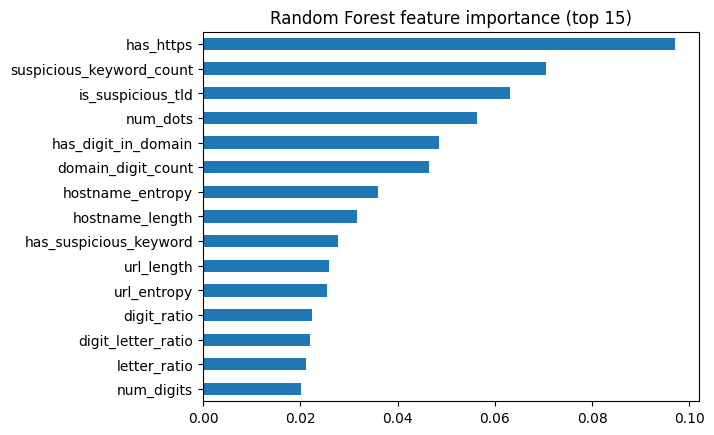

In [5]:
rf_importance = random_forest_importance(features, labels, FEATURE_NAMES)
pd.Series(rf_importance).head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Random Forest feature importance (top 15)')
plt.show()

## Redundant feature pairs (|r| >= 0.95)

In [6]:
pairs = highly_correlated_pairs(frame, FEATURE_NAMES, threshold=0.95)
pairs[:10]

[('num_hyphens', 'domain_hyphen_count', 1.0),
 ('num_slashes', 'path_depth', 1.0),
 ('num_at_symbols', 'has_at_before_host', 1.0),
 ('num_question_marks', 'has_query', 1.0),
 ('num_equals', 'num_query_parameters', 1.0),
 ('has_port', 'is_non_standard_port', 1.0),
 ('num_special_characters', 'num_equals', 0.9833362469608222),
 ('num_special_characters', 'num_query_parameters', 0.9833362469608222),
 ('url_length', 'num_letters', 0.982647245806349),
 ('query_length', 'num_equals', 0.9746101414095232)]